
# SuperbCommand – Multi-Asset CTA Strategy
## Notebook 05 — Portfolio Construction

**Purpose:** compare robust multi-asset portfolio-construction methods while keeping the SuperbCommand signal architecture fixed.

Notebook 04 identified three long/cash specifications worth carrying forward:

- `CORE`
- `PT_REDUCE_25`
- `PB_ADD_25`

Notebook 05 compares those under:

1. **Hierarchical Equal Weight**
2. **Hierarchical Inverse Volatility**
3. **Hierarchical Equal Risk Contribution (ERC)**
4. **Hierarchical ERC + Portfolio Volatility Targeting**

### Why hierarchical weighting?

The prototype universe contains different numbers of instruments in each asset class. A flat instrument-level allocation would therefore partly determine asset-class exposure according to how many proxies happened to be included.

Notebook 05 instead uses:

\[
\boxed{\text{Asset-class allocation} \rightarrow \text{Within-class allocation}}
\]

At both levels, the same weighting philosophy is applied.

### No-lookahead rule

All volatility and covariance estimates used for week \(t\) are calculated using data available **through week \(t-1\)**.

This notebook does not optimise signal hyperparameters and does not access 2026.


In [1]:

# ============================================================
# 5.1 — IMPORTS, DRIVE & PROJECT CONFIGURATION
# ============================================================
from __future__ import annotations
import json
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

PROJECT_ROOT = (
    Path("/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy")
    if IN_COLAB
    else Path.cwd() / "Multi-Asset CTA Strategy"
)

CONFIG_PATH = PROJECT_ROOT / "config" / "project_config.json"
if not CONFIG_PATH.exists():
    raise FileNotFoundError("Run Notebook 00 first.")

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

PATHS = {k: Path(v) for k, v in CFG["paths"].items()}
RESEARCH_END = pd.Timestamp(CFG["research_dates"]["research_end"])
HOLDOUT_START = pd.Timestamp(CFG["research_dates"]["holdout_start"])

if CFG["research_dates"]["unlock_holdout"]:
    raise RuntimeError("Notebook 05 cannot run with the holdout unlocked.")

SIGNAL_PATH = PATHS["data_processed"] / "superbcommand_weekly_signal_panel.parquet"
RETURN_PANEL_PATH = PATHS["data_processed"] / "04_strategy_return_panel.parquet"
META_PATH = PATHS["data_processed"] / "prototype_universe_metadata.csv"

for p in [SIGNAL_PATH, RETURN_PANEL_PATH, META_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"Required upstream file not found: {p}")

print("Project:", PROJECT_ROOT)
print("Research cutoff:", RESEARCH_END.date())
print("2026 holdout: LOCKED")


Mounted at /content/drive
Project: /content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy
Research cutoff: 2025-12-31
2026 holdout: LOCKED


In [2]:

# ============================================================
# 5.2 — LOAD UPSTREAM DATA
# ============================================================
panel = pd.read_parquet(SIGNAL_PATH)
strategy_returns = pd.read_parquet(RETURN_PANEL_PATH)
meta = pd.read_csv(META_PATH, index_col=0)

try:
    panel = panel.reorder_levels(["date", "ticker"]).sort_index()
except Exception:
    panel = panel.sort_index()

if panel.index.get_level_values("date").max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination detected in signal panel.")

if strategy_returns.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination detected in strategy return panel.")

tickers = sorted(meta.index.tolist())
asset_classes = ["equities", "rates", "commodities", "fx", "crypto"]

print("Markets:", len(tickers))
print("Asset classes:", asset_classes)
print("Strategy return panel:", strategy_returns.shape)


Markets: 11
Asset classes: ['equities', 'rates', 'commodities', 'fx', 'crypto']
Strategy return panel: (1095, 154)



## 5.3 Fixed portfolio settings

These are fixed research settings, not optimised conclusions:

- volatility lookback: about **13 weeks**;
- covariance lookback: about **52 weeks**;
- minimum covariance history: about **26 weeks**;
- target portfolio volatility: **10% annualised**;
- maximum gross leverage: **2.0×**.


In [3]:

# ============================================================
# 5.3 — SETTINGS
# ============================================================
VOL_LOOKBACK_WEEKS = max(4, int(round(float(CFG["defaults"]["vol_lookback_days"]) / 5)))
COV_LOOKBACK_WEEKS = max(13, int(round(float(CFG["defaults"]["covariance_lookback_days"]) / 5)))
MIN_COV_OBS_WEEKS = max(13, int(round(float(CFG["defaults"]["covariance_min_obs"]) / 5)))

PORTFOLIO_VOL_TARGET = float(CFG["defaults"]["portfolio_vol_target"])
MAX_GROSS_LEVERAGE = float(CFG["defaults"]["max_gross_leverage"])
TRADING_WEEKS_PER_YEAR = 52

PORTFOLIO_REBALANCE_COST_BPS = (
    float(CFG["defaults"]["transaction_cost_bps_one_way"])
    + float(CFG["defaults"]["slippage_bps_one_way"])
)
PORTFOLIO_REBALANCE_COST = PORTFOLIO_REBALANCE_COST_BPS / 10_000

COV_RIDGE = 1e-8

SURVIVING_VARIANTS = ["CORE", "PT_REDUCE_25", "PB_ADD_25"]

PORTFOLIO_METHODS = [
    "hier_equal_weight",
    "hier_inverse_vol",
    "hier_erc",
    "hier_erc_vol_target",
]

print("Vol lookback :", VOL_LOOKBACK_WEEKS)
print("Cov lookback :", COV_LOOKBACK_WEEKS)
print("Min cov obs  :", MIN_COV_OBS_WEEKS)
print("Vol target   :", f"{PORTFOLIO_VOL_TARGET:.1%}")
print("Max leverage :", MAX_GROSS_LEVERAGE)


Vol lookback : 13
Cov lookback : 50
Min cov obs  : 25
Vol target   : 10.0%
Max leverage : 2.0



## 5.4 Underlying market returns

Risk estimates are based on **underlying market returns**, not SuperbCommand strategy returns.

That avoids giving artificially large weights to markets simply because the strategy happened to spend long periods in cash.


In [4]:

# ============================================================
# 5.4 — UNDERLYING WEEKLY RETURNS
# ============================================================
underlying = {}

for ticker in tickers:
    x = panel.xs(ticker, level="ticker").copy()
    underlying[ticker] = x["close"].pct_change(fill_method=None).rename(ticker)

underlying_returns = pd.concat(underlying, axis=1).sort_index()

if underlying_returns.index.max() >= HOLDOUT_START:
    raise RuntimeError("Holdout contamination in underlying returns.")

print("Underlying return matrix:", underlying_returns.shape)
display(underlying_returns.tail())


Underlying return matrix: (1095, 11)


,BTC-USD,DBC,EEM,EFA,GLD,IEF,SHY,SPY,TIP,TLT,UUP
date,,,,,,,,,,,
2025-11-28,0.068498,0.023524,0.022976,0.027415,0.036364,0.003189,0.000602,0.036963,0.002162,0.007933,-0.006340
2025-12-05,-0.016845,0.011709,0.007732,0.006513,-0.003712,-0.007633,-0.000737,0.003366,-0.004399,-0.019124,-0.004608
2025-12-12,0.009874,-0.017574,-0.009134,0.007202,0.023290,-0.002902,0.001208,-0.005731,-0.001992,-0.009414,-0.004630
2025-12-19,-0.024006,-0.003054,0.004586,0.007148,0.009053,0.003766,0.001749,0.001234,0.000465,0.006306,0.004293
2025-12-26,-0.009102,0.026871,0.020104,0.011628,0.044409,0.002078,0.000363,0.014282,0.001001,0.002170,-0.006374



## 5.5 Weighting functions

Inverse volatility uses:

\[
w_i \propto \frac{1}{\sigma_i}
\]

ERC uses the covariance matrix and seeks approximately equal component risk contributions:

\[
RC_i \approx RC_j \quad \forall i,j.
\]


In [5]:

# ============================================================
# 5.5 — WEIGHTING FUNCTIONS
# ============================================================
def normalise_long_weights(w):
    w = np.asarray(w, dtype=float)
    w[~np.isfinite(w)] = 0.0
    w = np.clip(w, 0.0, None)
    s = w.sum()
    return np.ones(len(w)) / len(w) if s <= 0 else w / s

def inverse_vol_weights(returns_window):
    vol = returns_window.std(ddof=1).to_numpy(float)
    vol = np.where(np.isfinite(vol) & (vol > 0), vol, np.nan)
    inv = 1.0 / vol
    inv = np.where(np.isfinite(inv), inv, 0.0)
    return np.ones(len(vol)) / len(vol) if inv.sum() <= 0 else inv / inv.sum()

def regularise_cov(cov):
    cov = np.asarray(cov, dtype=float)
    cov = 0.5 * (cov + cov.T)
    diag_mean = np.nanmean(np.diag(cov))
    if not np.isfinite(diag_mean) or diag_mean <= 0:
        diag_mean = 1e-6
    return cov + np.eye(cov.shape[0]) * max(COV_RIDGE, diag_mean * 1e-6)

def erc_weights_from_cov(cov):
    cov = regularise_cov(cov)
    n = cov.shape[0]
    if n == 1:
        return np.array([1.0])

    target = np.ones(n) / n
    x0 = np.ones(n) / n

    def objective(w):
        pv = float(w @ cov @ w)
        if pv <= 0:
            return 1e6
        marginal = cov @ w
        comp = w * marginal
        total = comp.sum()
        if total <= 0:
            return 1e6
        rc_share = comp / total
        return float(np.sum((rc_share - target) ** 2))

    res = minimize(
        objective,
        x0,
        method="SLSQP",
        bounds=[(1e-8, 1.0)] * n,
        constraints={"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        options={"maxiter": 500, "ftol": 1e-12},
    )

    if not res.success:
        return np.ones(n) / n

    return normalise_long_weights(res.x)

def erc_weights(returns_window):
    complete = returns_window.dropna(how="any")
    if complete.shape[0] < 2:
        return np.ones(returns_window.shape[1]) / returns_window.shape[1]
    return erc_weights_from_cov(complete.cov().to_numpy(float))



## 5.6 Hierarchical allocation

For each date:

1. construct equal-weight asset-class proxy return histories;
2. determine asset-class weights;
3. determine within-class weights;
4. multiply the two levels.

For instrument \(i\) in class \(c\):

\[
w_i = w_c \times w_{i|c}.
\]


In [6]:

# ============================================================
# 5.6 — HIERARCHICAL WEIGHT ENGINE
# ============================================================
class_members = {
    c: [t for t in tickers if meta.loc[t, "asset_class"] == c]
    for c in asset_classes
}

display(pd.Series({k: len(v) for k, v in class_members.items()}, name="market_count").to_frame())

def asset_class_proxy_window(history):
    proxies = {}
    for c, members in class_members.items():
        available = [m for m in members if m in history.columns]
        if available:
            proxies[c] = history[available].mean(axis=1, skipna=True)
    return pd.DataFrame(proxies)

def weights_for_method(history, method):
    final = pd.Series(0.0, index=tickers, dtype=float)
    class_proxy = asset_class_proxy_window(history)

    active_classes = [
        c for c in asset_classes
        if c in class_proxy.columns
        and class_proxy[c].notna().sum() >= MIN_COV_OBS_WEEKS
    ]

    if not active_classes:
        return final

    class_hist = class_proxy[active_classes].tail(COV_LOOKBACK_WEEKS)

    if method == "hier_equal_weight":
        class_w = np.ones(len(active_classes)) / len(active_classes)
    elif method == "hier_inverse_vol":
        class_w = inverse_vol_weights(class_hist.tail(VOL_LOOKBACK_WEEKS))
    elif method in ("hier_erc", "hier_erc_vol_target"):
        class_w = erc_weights(class_hist)
    else:
        raise ValueError(f"Unknown method: {method}")

    class_weights = pd.Series(class_w, index=active_classes)

    for c in active_classes:
        members = [
            m for m in class_members[c]
            if history[m].notna().sum() >= MIN_COV_OBS_WEEKS
        ]
        if not members:
            continue

        h = history[members]

        if method == "hier_equal_weight":
            inner_w = np.ones(len(members)) / len(members)
        elif method == "hier_inverse_vol":
            inner_w = inverse_vol_weights(h.tail(VOL_LOOKBACK_WEEKS))
        else:
            inner_w = erc_weights(h.tail(COV_LOOKBACK_WEEKS))

        final.loc[members] = class_weights.loc[c] * inner_w

    if final.sum() > 0:
        final = final / final.sum()

    return final


,market_count
equities,3
rates,4
commodities,2
fx,1
crypto,1



## 5.7 Volatility targeting

Only `hier_erc_vol_target` is scaled to a 10% annualised ex-ante volatility target, capped at 2.0× gross exposure.


In [7]:

# ============================================================
# 5.7 — VOLATILITY TARGETING
# ============================================================
def ex_ante_portfolio_vol(weights, history):
    active = weights[weights.abs() > 1e-12].index.tolist()
    if not active:
        return np.nan

    h = history[active].tail(COV_LOOKBACK_WEEKS).dropna(how="any")
    if len(h) < MIN_COV_OBS_WEEKS:
        return np.nan

    cov = regularise_cov(h.cov().to_numpy(float))
    w = weights.loc[active].to_numpy(float)
    weekly_var = float(w @ cov @ w)

    if weekly_var <= 0:
        return np.nan

    return np.sqrt(weekly_var) * np.sqrt(TRADING_WEEKS_PER_YEAR)

def apply_vol_target(weights, history):
    vol = ex_ante_portfolio_vol(weights, history)
    if pd.isna(vol) or vol <= 0:
        return weights.copy(), 1.0, vol

    lev = min(PORTFOLIO_VOL_TARGET / vol, MAX_GROSS_LEVERAGE)
    return weights * lev, lev, vol



## 5.8 Generate weekly weights

Weights applied to week \(t\) are based exclusively on history ending at week \(t-1\).


In [8]:

# ============================================================
# 5.8 — BUILD WEIGHT HISTORIES
# ============================================================
weight_history = {}
leverage_history = {}
ex_ante_vol_history = {}

dates = underlying_returns.index

for method in PORTFOLIO_METHODS:
    rows, levs, vols = [], [], []

    for i, date in enumerate(dates):
        history = underlying_returns.iloc[:i].copy()

        if len(history) < MIN_COV_OBS_WEEKS:
            w = pd.Series(0.0, index=tickers)
            lev, exvol = 0.0, np.nan
        else:
            w = weights_for_method(history, method)

            if method == "hier_erc_vol_target":
                w, lev, exvol = apply_vol_target(w, history)
            else:
                lev = float(w.abs().sum())
                exvol = ex_ante_portfolio_vol(w, history)

        w.name = date
        rows.append(w)
        levs.append(lev)
        vols.append(exvol)

    weight_history[method] = pd.DataFrame(rows, index=dates)
    leverage_history[method] = pd.Series(levs, index=dates, name=method)
    ex_ante_vol_history[method] = pd.Series(vols, index=dates, name=method)

print("Weight histories created.")


Weight histories created.


In [9]:

# ============================================================
# 5.9 — LATEST WEIGHTS
# ============================================================
latest_rows = []

for method in PORTFOLIO_METHODS:
    w = weight_history[method].iloc[-1]
    for ticker, value in w.items():
        latest_rows.append({
            "method": method,
            "ticker": ticker,
            "asset_class": meta.loc[ticker, "asset_class"],
            "weight": value,
        })

latest_weights = pd.DataFrame(latest_rows)

display(
    latest_weights.pivot(
        index=["ticker", "asset_class"],
        columns="method",
        values="weight",
    )
)


,method,hier_equal_weight,hier_erc,hier_erc_vol_target,hier_inverse_vol
ticker,asset_class,,,,
BTC-USD,crypto,0.200000,1.527616e-01,1.249378e-01,0.031242
DBC,commodities,0.100000,2.621450e-01,2.143983e-01,0.088193
EEM,equities,0.066667,1.160217e-01,9.488968e-02,0.028258
EFA,equities,0.066667,1.172146e-01,9.586529e-02,0.037491
GLD,commodities,0.100000,2.371039e-01,1.939181e-01,0.062237
IEF,rates,0.050000,1.197335e-09,9.792540e-10,0.060628
SHY,rates,0.050000,6.407793e-09,5.240687e-09,0.239265
SPY,equities,0.066667,1.147532e-01,9.385218e-02,0.039854
TIP,rates,0.050000,1.765557e-09,1.443981e-09,0.103439


In [10]:

# ============================================================
# 5.10 — LATEST ASSET-CLASS WEIGHTS
# ============================================================
latest_class_rows = []

for method in PORTFOLIO_METHODS:
    w = weight_history[method].iloc[-1]
    for c in asset_classes:
        latest_class_rows.append({
            "method": method,
            "asset_class": c,
            "weight": w[class_members[c]].sum(),
        })

latest_class_weights = pd.DataFrame(latest_class_rows)

display(
    latest_class_weights.pivot(
        index="asset_class",
        columns="method",
        values="weight",
    )
)


method,hier_equal_weight,hier_erc,hier_erc_vol_target,hier_inverse_vol
asset_class,,,,
commodities,0.2,4.992489e-01,4.083164e-01,0.150430
crypto,0.2,1.527616e-01,1.249378e-01,0.031242
equities,0.2,3.479895e-01,2.846072e-01,0.105603
fx,0.2,1.000000e-08,8.178613e-09,0.279098
rates,0.2,1.000000e-08,8.178613e-09,0.433627



## 5.11 Combine portfolio weights with Notebook 04 strategy returns

Notebook 04 already includes the one-week SuperbCommand signal lag and market-level prototype costs.

Notebook 05 adds dynamic portfolio weighting plus additional portfolio-rebalancing cost.


In [11]:

# ============================================================
# 5.11 — EXTRACT SURVIVING RETURN MATRICES
# ============================================================
variant_return_matrices = {}

for variant in SURVIVING_VARIANTS:
    cols = []

    for ticker in tickers:
        key = (ticker, variant, "long_cash")
        if key not in strategy_returns.columns:
            raise KeyError(f"Missing Notebook 04 return series: {key}")
        cols.append(strategy_returns[key].rename(ticker))

    variant_return_matrices[variant] = pd.concat(cols, axis=1).reindex(underlying_returns.index)

print("Surviving strategy return matrices loaded.")


Surviving strategy return matrices loaded.


In [12]:

# ============================================================
# 5.12 — PORTFOLIO BACKTEST ENGINE
# ============================================================
portfolio_results = {}
portfolio_turnover = {}
portfolio_rebalance_costs = {}

for variant in SURVIVING_VARIANTS:
    ret_matrix = variant_return_matrices[variant]

    for method in PORTFOLIO_METHODS:
        W = weight_history[method].reindex(ret_matrix.index).fillna(0.0)

        turnover = W.diff().abs().sum(axis=1)
        first_nonzero = np.flatnonzero(W.abs().sum(axis=1).to_numpy() > 0)

        if len(first_nonzero):
            j = first_nonzero[0]
            turnover.iloc[j] = W.iloc[j].abs().sum()

        cost = turnover.fillna(0.0) * PORTFOLIO_REBALANCE_COST
        gross = (W * ret_matrix.fillna(0.0)).sum(axis=1)
        net = gross - cost

        key = (variant, method)
        portfolio_results[key] = net
        portfolio_turnover[key] = turnover
        portfolio_rebalance_costs[key] = cost

print("Portfolio backtests:", len(portfolio_results))


Portfolio backtests: 12


In [13]:

# ============================================================
# 5.13 — PERFORMANCE FUNCTIONS
# ============================================================
def max_drawdown(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = (1 + r).cumprod()
    return float((wealth / wealth.cummax() - 1).min())

def cagr(r):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    wealth = float((1 + r).prod())
    years = len(r) / TRADING_WEEKS_PER_YEAR
    return np.nan if wealth <= 0 or years <= 0 else wealth ** (1 / years) - 1

def ann_vol(r):
    r = pd.Series(r).dropna()
    return np.nan if len(r) < 2 else float(r.std(ddof=1) * np.sqrt(TRADING_WEEKS_PER_YEAR))

def sharpe(r):
    r = pd.Series(r).dropna()
    if len(r) < 2 or r.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / r.std(ddof=1) * np.sqrt(TRADING_WEEKS_PER_YEAR))

def sortino(r):
    r = pd.Series(r).dropna()
    d = r[r < 0]
    if len(d) < 2 or d.std(ddof=1) == 0:
        return np.nan
    return float(r.mean() / d.std(ddof=1) * np.sqrt(TRADING_WEEKS_PER_YEAR))

def calmar(r):
    ca, md = cagr(r), max_drawdown(r)
    return np.nan if pd.isna(ca) or pd.isna(md) or md == 0 else ca / abs(md)

def metrics(r, turnover=None, costs=None):
    r = pd.Series(r).dropna()
    out = {
        "cagr": cagr(r),
        "ann_vol": ann_vol(r),
        "sharpe": sharpe(r),
        "sortino": sortino(r),
        "max_drawdown": max_drawdown(r),
        "calmar": calmar(r),
        "best_week": r.max() if len(r) else np.nan,
        "worst_week": r.min() if len(r) else np.nan,
        "positive_week_rate": (r > 0).mean() if len(r) else np.nan,
    }
    if turnover is not None:
        out["annual_portfolio_turnover"] = pd.Series(turnover).fillna(0).mean() * 52
    if costs is not None:
        out["annual_rebalance_cost"] = pd.Series(costs).fillna(0).mean() * 52
    return out


In [14]:

# ============================================================
# 5.14 — PERFORMANCE TABLE
# ============================================================
rows = []

for (variant, method), r in portfolio_results.items():
    rows.append({
        "variant": variant,
        "portfolio_method": method,
        **metrics(
            r,
            turnover=portfolio_turnover[(variant, method)],
            costs=portfolio_rebalance_costs[(variant, method)],
        ),
    })

performance = pd.DataFrame(rows)
display(performance.sort_values("sharpe", ascending=False))


,variant,portfolio_method,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate,annual_portfolio_turnover,annual_rebalance_cost
5,PT_REDUCE_25,hier_inverse_vol,0.036904,0.033563,1.096897,1.477292,-0.066441,0.555439,0.027660,-0.030534,0.515068,3.083230,0.000925
1,CORE,hier_inverse_vol,0.037469,0.034223,1.092313,1.473897,-0.069233,0.541204,0.027660,-0.031292,0.514155,3.083230,0.000925
9,PB_ADD_25,hier_inverse_vol,0.038052,0.035728,1.063531,1.423092,-0.068087,0.558879,0.027660,-0.033671,0.513242,3.083230,0.000925
4,PT_REDUCE_25,hier_equal_weight,0.099823,0.098849,1.012590,1.348914,-0.179031,0.557576,0.097780,-0.114942,0.500457,0.106058,0.000032
0,CORE,hier_equal_weight,0.099837,0.100298,0.999549,1.321345,-0.169638,0.588529,0.097783,-0.116503,0.499543,0.106058,0.000032
8,PB_ADD_25,hier_equal_weight,0.101818,0.105103,0.975708,1.281412,-0.192870,0.527911,0.097139,-0.120557,0.497717,0.106058,0.000032
7,PT_REDUCE_25,hier_erc_vol_target,0.054637,0.078525,0.717328,0.884306,-0.189809,0.287852,0.051492,-0.098741,0.496804,5.103870,0.001531
3,CORE,hier_erc_vol_target,0.055781,0.080379,0.716148,0.880792,-0.197378,0.282609,0.051492,-0.101076,0.496804,5.103870,0.001531
6,PT_REDUCE_25,hier_erc,0.058818,0.085623,0.711070,0.852352,-0.206731,0.284514,0.048074,-0.126155,0.496804,3.704216,0.001111
11,PB_ADD_25,hier_erc_vol_target,0.057507,0.084125,0.707403,0.870926,-0.208822,0.275386,0.052136,-0.107475,0.494064,5.103870,0.001531


## 5.15 Core strategy — weighting-method comparison

In [15]:

# ============================================================
# 5.15 — CORE METHOD COMPARISON
# ============================================================
core_comparison = (
    performance[performance["variant"] == "CORE"]
    .set_index("portfolio_method")
    .sort_values("sharpe", ascending=False)
)

display(core_comparison)


,variant,cagr,ann_vol,sharpe,sortino,max_drawdown,calmar,best_week,worst_week,positive_week_rate,annual_portfolio_turnover,annual_rebalance_cost
portfolio_method,,,,,,,,,,,,
hier_inverse_vol,CORE,0.037469,0.034223,1.092313,1.473897,-0.069233,0.541204,0.027660,-0.031292,0.514155,3.083230,0.000925
hier_equal_weight,CORE,0.099837,0.100298,0.999549,1.321345,-0.169638,0.588529,0.097783,-0.116503,0.499543,0.106058,0.000032
hier_erc_vol_target,CORE,0.055781,0.080379,0.716148,0.880792,-0.197378,0.282609,0.051492,-0.101076,0.496804,5.103870,0.001531
hier_erc,CORE,0.058951,0.087459,0.699438,0.834340,-0.209880,0.280880,0.050268,-0.129138,0.496804,3.704216,0.001111


## 5.16 Tactical-variant comparison by weighting method

In [16]:

# ============================================================
# 5.16 — VARIANT COMPARISON
# ============================================================
variant_method_table = performance.pivot(
    index="variant",
    columns="portfolio_method",
    values="sharpe",
)

display(variant_method_table)


portfolio_method,hier_equal_weight,hier_erc,hier_erc_vol_target,hier_inverse_vol
variant,,,,
CORE,0.999549,0.699438,0.716148,1.092313
PB_ADD_25,0.975708,0.695406,0.707403,1.063531
PT_REDUCE_25,1.012590,0.711070,0.717328,1.096897



## 5.17 Weight stability and concentration

A more sophisticated risk model is not automatically preferable if it generates unstable weights or excessive turnover.


In [17]:

# ============================================================
# 5.17 — WEIGHT DIAGNOSTICS
# ============================================================
weight_diag_rows = []

for method, W in weight_history.items():
    valid = W[W.abs().sum(axis=1) > 0].copy()
    if len(valid) == 0:
        continue

    weekly_turnover = valid.diff().abs().sum(axis=1)
    max_instr = valid.abs().max(axis=1)

    class_weight_df = pd.DataFrame(index=valid.index)
    for c, members in class_members.items():
        class_weight_df[c] = valid[members].abs().sum(axis=1)

    gross = valid.abs().sum(axis=1)
    lev = leverage_history[method].reindex(valid.index)

    weight_diag_rows.append({
        "portfolio_method": method,
        "mean_weekly_weight_turnover": weekly_turnover.mean(),
        "annualised_weight_turnover": weekly_turnover.mean() * 52,
        "mean_max_instrument_weight": max_instr.mean(),
        "mean_max_asset_class_weight": class_weight_df.max(axis=1).mean(),
        "mean_gross_exposure": gross.mean(),
        "median_gross_exposure": gross.median(),
        "max_gross_exposure": gross.max(),
        "mean_leverage_scalar": lev.mean(),
        "max_leverage_scalar": lev.max(),
    })

weight_diagnostics = pd.DataFrame(weight_diag_rows).set_index("portfolio_method")
display(weight_diagnostics)


,mean_weekly_weight_turnover,annualised_weight_turnover,mean_max_instrument_weight,mean_max_asset_class_weight,mean_gross_exposure,median_gross_exposure,max_gross_exposure,mean_leverage_scalar,max_leverage_scalar
portfolio_method,,,,,,,,,
hier_equal_weight,0.001154,0.059994,0.223823,0.232398,1.00000,1.000000,1.0,1.00000,1.0
hier_inverse_vol,0.059800,3.109576,0.331342,0.408069,1.00000,1.000000,1.0,1.00000,1.0
hier_erc,0.072032,3.745665,0.350015,0.539058,1.00000,1.000000,1.0,1.00000,1.0
hier_erc_vol_target,0.098668,5.130718,0.464640,0.678968,1.26785,1.075709,2.0,1.26785,2.0


## 5.18 Volatility-target diagnostics

In [18]:

# ============================================================
# 5.18 — VOL TARGET DIAGNOSTICS
# ============================================================
vt_rows = []

for variant in SURVIVING_VARIANTS:
    r = portfolio_results[(variant, "hier_erc_vol_target")]

    realised = (
        r.rolling(26, min_periods=13)
        .std(ddof=1)
        * np.sqrt(52)
    )

    exante = ex_ante_vol_history["hier_erc_vol_target"].reindex(r.index)
    leverage = leverage_history["hier_erc_vol_target"].reindex(r.index)

    vt_rows.append({
        "variant": variant,
        "target_vol": PORTFOLIO_VOL_TARGET,
        "mean_exante_unlevered_vol": exante.mean(),
        "mean_leverage": leverage.mean(),
        "median_leverage": leverage.median(),
        "max_leverage": leverage.max(),
        "mean_realised_26w_vol": realised.mean(),
        "median_realised_26w_vol": realised.median(),
    })

vol_target_diagnostics = pd.DataFrame(vt_rows)
display(vol_target_diagnostics)


,variant,target_vol,mean_exante_unlevered_vol,mean_leverage,median_leverage,max_leverage,mean_realised_26w_vol,median_realised_26w_vol
0,CORE,0.1,0.098816,1.238659,1.060111,2.0,0.070018,0.071634
1,PT_REDUCE_25,0.1,0.098816,1.238659,1.060111,2.0,0.068538,0.070690
2,PB_ADD_25,0.1,0.098816,1.238659,1.060111,2.0,0.073319,0.074941


## 5.19 Core equity curves

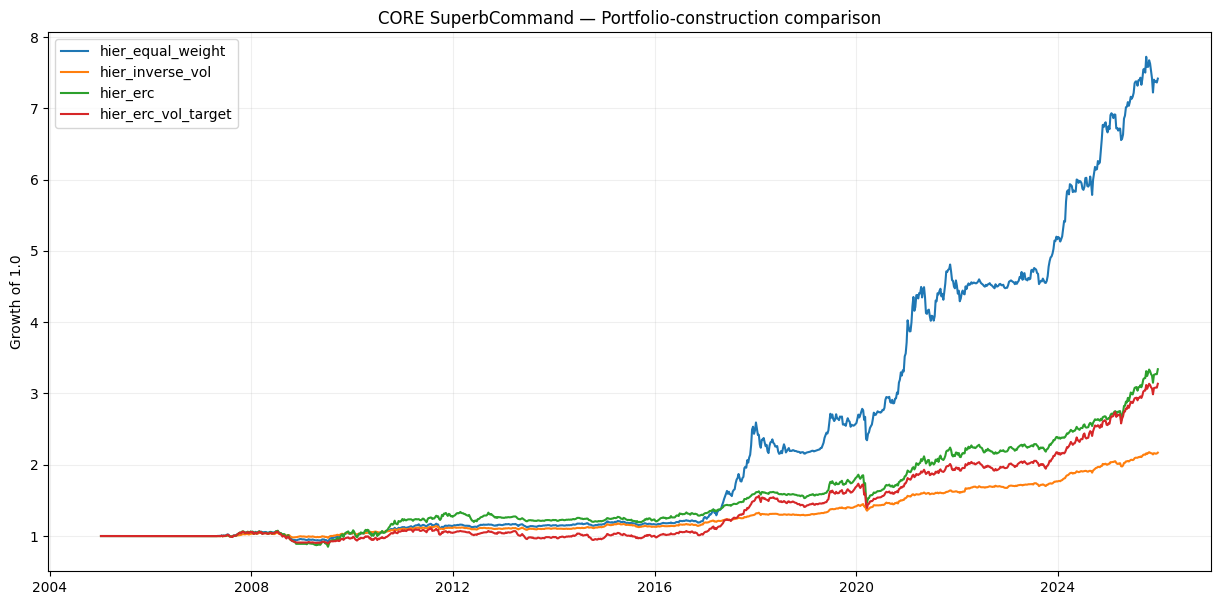

In [19]:

# ============================================================
# 5.19 — CORE EQUITY CURVES
# ============================================================
fig, ax = plt.subplots(figsize=(15, 7))

for method in PORTFOLIO_METHODS:
    r = portfolio_results[("CORE", method)].fillna(0)
    eq = (1 + r).cumprod()
    ax.plot(eq.index, eq, label=method)

ax.set_title("CORE SuperbCommand — Portfolio-construction comparison")
ax.set_ylabel("Growth of 1.0")
ax.legend()
ax.grid(alpha=0.2)
plt.show()


## 5.20 Core drawdowns

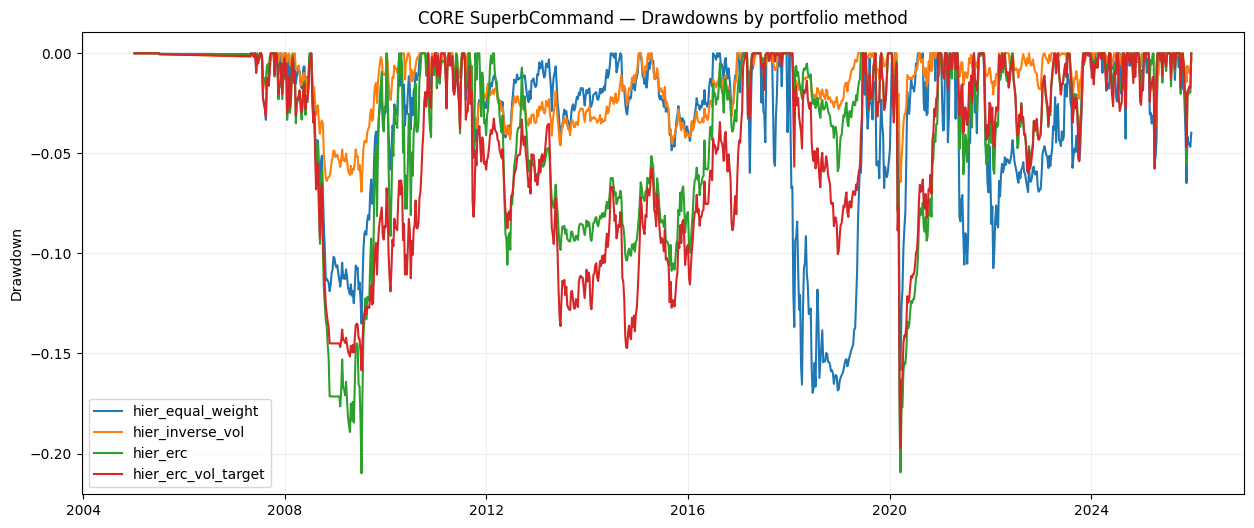

In [20]:

# ============================================================
# 5.20 — CORE DRAWDOWNS
# ============================================================
fig, ax = plt.subplots(figsize=(15, 6))

for method in PORTFOLIO_METHODS:
    r = portfolio_results[("CORE", method)].fillna(0)
    wealth = (1 + r).cumprod()
    dd = wealth / wealth.cummax() - 1
    ax.plot(dd.index, dd, label=method)

ax.set_title("CORE SuperbCommand — Drawdowns by portfolio method")
ax.set_ylabel("Drawdown")
ax.legend()
ax.grid(alpha=0.2)
plt.show()


## 5.21 Asset-class allocation through time

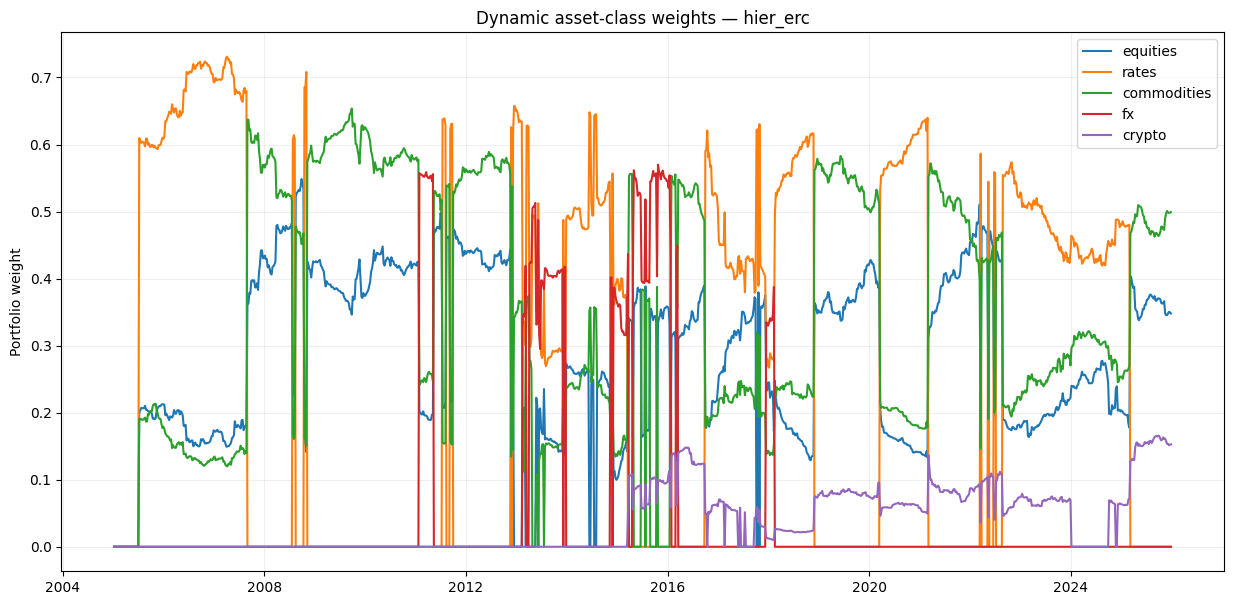

In [21]:

# ============================================================
# 5.21 — ASSET-CLASS WEIGHTS THROUGH TIME
# ============================================================
PLOT_METHOD = "hier_erc"

W = weight_history[PLOT_METHOD].copy()
class_weights_ts = pd.DataFrame(index=W.index)

for c, members in class_members.items():
    class_weights_ts[c] = W[members].sum(axis=1)

fig, ax = plt.subplots(figsize=(15, 7))

for c in asset_classes:
    ax.plot(class_weights_ts.index, class_weights_ts[c], label=c)

ax.set_title(f"Dynamic asset-class weights — {PLOT_METHOD}")
ax.set_ylabel("Portfolio weight")
ax.legend()
ax.grid(alpha=0.2)
plt.show()


## 5.22 Fixed stress-period comparison

In [22]:

# ============================================================
# 5.22 — STRESS PERIODS
# ============================================================
STRESS_PERIODS = {
    "Global Financial Crisis": ("2007-07-01", "2009-03-31"),
    "Euro-area stress": ("2011-05-01", "2012-07-31"),
    "COVID crash": ("2020-02-01", "2020-04-30"),
    "2022 inflation/rates shock": ("2022-01-01", "2022-12-31"),
}

stress_rows = []

for period, (start, end) in STRESS_PERIODS.items():
    for variant in SURVIVING_VARIANTS:
        for method in PORTFOLIO_METHODS:
            r = portfolio_results[(variant, method)].loc[start:end].dropna()
            if len(r) == 0:
                continue

            stress_rows.append({
                "period": period,
                "variant": variant,
                "portfolio_method": method,
                "weeks": len(r),
                "total_return": (1 + r).prod() - 1,
                "max_drawdown": max_drawdown(r),
                "worst_week": r.min(),
            })

stress = pd.DataFrame(stress_rows)
display(stress)


,period,variant,portfolio_method,weeks,total_return,max_drawdown,worst_week
0,Global Financial Crisis,CORE,hier_equal_weight,91,-5.838105e-02,-0.118898,-0.018737
1,Global Financial Crisis,CORE,hier_inverse_vol,91,-8.964760e-03,-0.063843,-0.015752
2,Global Financial Crisis,CORE,hier_erc,91,-1.122226e-01,-0.176436,-0.041337
3,Global Financial Crisis,CORE,hier_erc_vol_target,91,-9.410519e-02,-0.146809,-0.029349
4,Global Financial Crisis,PT_REDUCE_25,hier_equal_weight,91,-5.342073e-02,-0.116756,-0.018746
5,Global Financial Crisis,PT_REDUCE_25,hier_inverse_vol,91,-6.474964e-03,-0.061787,-0.015752
6,Global Financial Crisis,PT_REDUCE_25,hier_erc,91,-1.020331e-01,-0.175230,-0.041337
7,Global Financial Crisis,PT_REDUCE_25,hier_erc_vol_target,91,-8.523555e-02,-0.144316,-0.029349
8,Global Financial Crisis,PB_ADD_25,hier_equal_weight,91,-5.712607e-02,-0.121088,-0.019899
9,Global Financial Crisis,PB_ADD_25,hier_inverse_vol,91,-7.694149e-03,-0.064264,-0.016488


## 5.23 Save outputs

In [23]:

# ============================================================
# 5.23 — SAVE OUTPUTS
# ============================================================
PERF_PATH = PATHS["results"] / "05_portfolio_construction_performance.csv"
WEIGHT_DIAG_PATH = PATHS["results"] / "05_weight_diagnostics.csv"
VOL_DIAG_PATH = PATHS["results"] / "05_vol_target_diagnostics.csv"
STRESS_PATH = PATHS["results"] / "05_portfolio_stress_summary.csv"
LATEST_WEIGHT_PATH = PATHS["results"] / "05_latest_weights.csv"
WEIGHTS_PATH = PATHS["data_processed"] / "05_portfolio_weights.parquet"
PORT_RETURNS_PATH = PATHS["data_processed"] / "05_portfolio_return_panel.parquet"

performance.to_csv(PERF_PATH, index=False)
weight_diagnostics.to_csv(WEIGHT_DIAG_PATH)
vol_target_diagnostics.to_csv(VOL_DIAG_PATH, index=False)
stress.to_csv(STRESS_PATH, index=False)
latest_weights.to_csv(LATEST_WEIGHT_PATH, index=False)

weight_panel = pd.concat(weight_history, axis=1)
weight_panel.columns.names = ["portfolio_method", "ticker"]
weight_panel.to_parquet(WEIGHTS_PATH)

port_return_panel = pd.concat(portfolio_results, axis=1)
port_return_panel.columns = pd.MultiIndex.from_tuples(
    port_return_panel.columns,
    names=["variant", "portfolio_method"],
)
port_return_panel.to_parquet(PORT_RETURNS_PATH)

print("Saved Notebook 05 outputs.")


Saved Notebook 05 outputs.


## 5.24 Validation suite

In [24]:

# ============================================================
# 5.24 — VALIDATION SUITE
# ============================================================
checks = {}

checks["holdout_absent"] = underlying_returns.index.max() <= RESEARCH_END
checks["all_variants_present"] = set(performance["variant"]) == set(SURVIVING_VARIANTS)
checks["all_methods_present"] = set(performance["portfolio_method"]) == set(PORTFOLIO_METHODS)

unlevered_ok = True
for method in ["hier_equal_weight", "hier_inverse_vol", "hier_erc"]:
    W = weight_history[method]
    active = W[W.abs().sum(axis=1) > 0]
    if len(active) and not np.allclose(active.sum(axis=1), 1.0, atol=1e-6):
        unlevered_ok = False
        break

checks["unlevered_weights_sum_to_one"] = unlevered_ok

Wvt = weight_history["hier_erc_vol_target"]
checks["vol_target_leverage_cap_respected"] = (
    Wvt.abs().sum(axis=1).max() <= MAX_GROSS_LEVERAGE + 1e-8
)

checks["portfolio_return_panel_written"] = PORT_RETURNS_PATH.exists()
checks["weight_panel_written"] = WEIGHTS_PATH.exists()
checks["result_files_written"] = all(
    p.exists()
    for p in [PERF_PATH, WEIGHT_DIAG_PATH, VOL_DIAG_PATH, STRESS_PATH, LATEST_WEIGHT_PATH]
)

validation = pd.DataFrame({
    "check": list(checks.keys()),
    "passed": list(checks.values()),
})

print(validation.to_string(index=False))

if not all(checks.values()):
    failed = [k for k, v in checks.items() if not v]
    raise RuntimeError(f"Notebook 05 validation failed: {failed}")

print("\n" + "=" * 78)
print("NOTEBOOK 05 STATUS: PASS")
print("=" * 78)
print("Portfolio-construction research completed.")
print("No portfolio method has yet been declared optimal.")
print("No signal hyperparameters were optimised.")
print("2026 holdout: NOT ACCESSED")
print("Proceed to Notebook 06 — Baseline Backtests.")


                            check  passed
                   holdout_absent    True
             all_variants_present    True
              all_methods_present    True
     unlevered_weights_sum_to_one    True
vol_target_leverage_cap_respected    True
   portfolio_return_panel_written    True
             weight_panel_written    True
             result_files_written    True

NOTEBOOK 05 STATUS: PASS
Portfolio-construction research completed.
No portfolio method has yet been declared optimal.
No signal hyperparameters were optimised.
2026 holdout: NOT ACCESSED
Proceed to Notebook 06 — Baseline Backtests.


In [25]:

# ============================================================
# 5.25 — WRITE MANIFEST
# ============================================================
manifest = {
    "notebook_id": "05",
    "notebook_name": "Portfolio Construction",
    "project_name": "SuperbCommand – Multi-Asset CTA Strategy",
    "run_timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "research_end": str(RESEARCH_END.date()),
    "holdout_accessed": False,
    "surviving_variants": SURVIVING_VARIANTS,
    "portfolio_methods": PORTFOLIO_METHODS,
    "hierarchical_weighting": True,
    "vol_lookback_weeks": VOL_LOOKBACK_WEEKS,
    "cov_lookback_weeks": COV_LOOKBACK_WEEKS,
    "minimum_covariance_observations_weeks": MIN_COV_OBS_WEEKS,
    "portfolio_vol_target": PORTFOLIO_VOL_TARGET,
    "max_gross_leverage": MAX_GROSS_LEVERAGE,
    "portfolio_rebalance_cost_bps": PORTFOLIO_REBALANCE_COST_BPS,
    "outputs": {
        "performance": str(PERF_PATH),
        "weight_diagnostics": str(WEIGHT_DIAG_PATH),
        "vol_target_diagnostics": str(VOL_DIAG_PATH),
        "stress_summary": str(STRESS_PATH),
        "latest_weights": str(LATEST_WEIGHT_PATH),
        "weight_panel": str(WEIGHTS_PATH),
        "portfolio_return_panel": str(PORT_RETURNS_PATH),
    },
    "status": "PASS",
}

MANIFEST_PATH = PATHS["manifests"] / "05_portfolio_construction_manifest.json"

with open(MANIFEST_PATH, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

print("Saved manifest:")
print(MANIFEST_PATH)


Saved manifest:
/content/drive/MyDrive/Colab Notebooks/SuperbCommand/Multi-Asset CTA Strategy/manifests/05_portfolio_construction_manifest.json



---

# End of Notebook 05

Notebook 05 compares the surviving SuperbCommand long/cash variants under hierarchical equal weighting, inverse volatility, ERC, and ERC with volatility targeting.

The highest full-sample Sharpe ratio is **not automatically selected** as the final model.

## Next notebook

**Notebook 06 — Baseline Backtests**
